In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn import metrics
from sklearn.metrics import r2_score

In [ ]:
data=pd.read_csv('/content/car data.csv')

In [ ]:
data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ciaz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [ ]:
data.drop('Car_Name',axis=1,inplace=True)

In [ ]:
data

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder=LabelEncoder()

In [ ]:
data.Fuel_Type=encoder.fit_transform(data.Fuel_Type)
data.Seller_Type=encoder.fit_transform(data.Seller_Type)
data.Transmission=encoder.fit_transform(data.Transmission)

In [ ]:
data.shape

(301, 8)

Outlier removal

In [ ]:
outlier_pp = data[data['Present_Price'] >25]
data = data[~data.index.isin(outlier_pp.index)]

In [ ]:
outlier_sp = data[data['Selling_Price'] >17]
data = data[~data.index.isin(outlier_sp.index)]

In [ ]:
outlier_km = data[data['Kms_Driven'] >100000]
data = data[~data.index.isin(outlier_km.index)]

Train test split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=data.drop('Selling_Price',axis=1)
y=data.iloc[:,[1] ]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

Preprocessing

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [ ]:
stdScaler = StandardScaler()
stdScaler.fit(x_train[['Present_Price']])

StandardScaler()

In [ ]:
x_train['Present_Price']=stdScaler.transform(x_train[['Present_Price']])
x_test['Present_Price']=stdScaler.transform(x_test[['Present_Price']])

In [ ]:
tarScaler = StandardScaler()

In [ ]:
tarScaler.fit(y_train[['Selling_Price']])
y_train['Selling_Price']=tarScaler.transform(y_train[['Selling_Price']])
y_test['Selling_Price']=tarScaler.transform(y_test[['Selling_Price']])

In [ ]:
mmScaler = MinMaxScaler()
mmScaler.fit(x_train[['Kms_Driven']])

MinMaxScaler()

In [ ]:
x_train['Kms_Driven']=mmScaler.transform(x_train[['Kms_Driven']])
x_test['Kms_Driven']=mmScaler.transform(x_test[['Kms_Driven']])

Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr=LinearRegression()

In [ ]:
lr.fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)

Metrics for linear regression

In [ ]:
r2=r2_score(y_test,y_pred_lr)
r2

0.8087872917066252

In [ ]:
mae=metrics.mean_absolute_error(y_test,y_pred_lr)
mse=metrics.mean_squared_error(y_test,y_pred_lr)
print("mae=",mae)
print("mse=",mse)

mae= 0.3321379908359329
mse= 0.2437275062882727


Random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf=RandomForestRegressor(n_estimators=150,random_state=42)

In [ ]:
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
r2=r2_score(y_test,y_pred_rf)
r2

0.9275469953585207

In [ ]:
mae=metrics.mean_absolute_error(y_test,y_pred_rf)
mse=metrics.mean_squared_error(y_test,y_pred_rf)
print("mae=",mae)
print("mse=",mse)

mae= 0.1827207480224079
mse= 0.09235155080417966


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pickle

# Train Random Forest model
rf = RandomForestRegressor(n_estimators=150, random_state=42)
rf.fit(x_train, y_train)

# Predictions and evaluation
y_pred_rf = rf.predict(x_test)
r2 = r2_score(y_test, y_pred_rf)
mae = metrics.mean_absolute_error(y_test, y_pred_rf)
mse = metrics.mean_squared_error(y_test, y_pred_rf)

# Print evaluation metrics
print("R2 Score:", r2)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)

# Save model to pickle file
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(rf, file)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


R2 Score: 0.9275469953585207
Mean Absolute Error (MAE): 0.1827207480224079
Mean Squared Error (MSE): 0.09235155080417966


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(x)
data['Cluster'] = kmeans.labels_

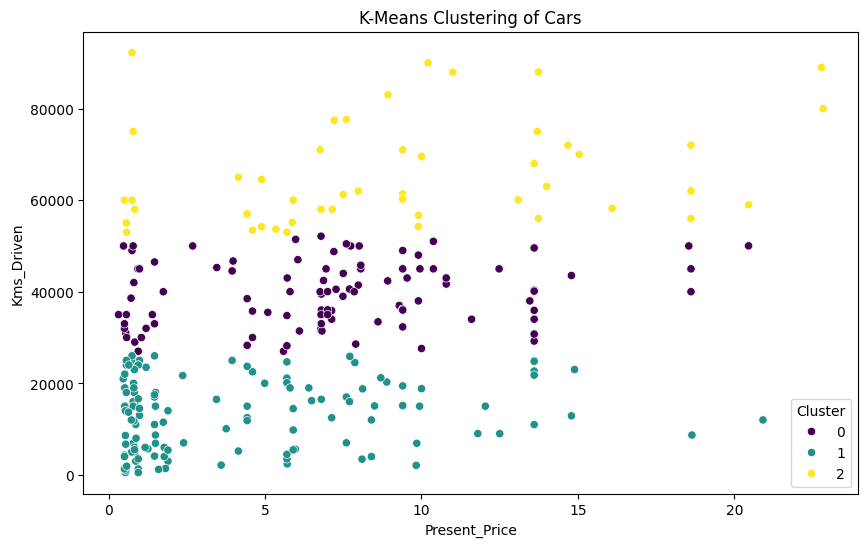

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Present_Price', y='Kms_Driven', hue='Cluster', data=data, palette='viridis')
plt.title('K-Means Clustering of Cars')
plt.show()

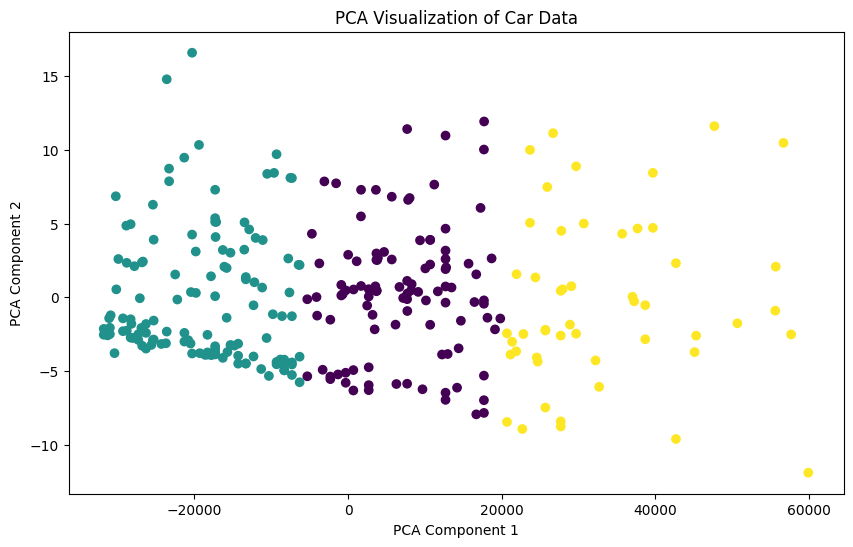

In [ ]:
# PCA for dimensionality reduction
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

# Plot PCA results
plt.figure(figsize=(10, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=kmeans.labels_, cmap='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA Visualization of Car Data')
plt.show()

XG Boost regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
gr=GradientBoostingRegressor(random_state=42)

In [ ]:
gr.fit(x_train,y_train)
y_pred_xg=gr.predict(x_test)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [ ]:
r2=r2_score(y_test,y_pred_xg)
r2

0.9264979138745917

In [ ]:
mae=metrics.mean_absolute_error(y_test,y_pred_xg)
mse=metrics.mean_squared_error(y_test,y_pred_xg)
print("mae=",mae)
print("mse=",mse)

mae= 0.16683427123144837
mse= 0.09368875279380337


Making prediction

In [ ]:
features=x_train.columns
print(features)

Index(['Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type',
       'Transmission', 'Owner'],
      dtype='object')


In [ ]:
data.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,2,0,1,0
1,2013,4.75,9.54,43000,1,0,1,0
2,2017,7.25,9.85,6900,2,0,1,0
3,2011,2.85,4.15,5200,2,0,1,0
4,2014,4.60,6.87,42450,1,0,1,0


In [ ]:
inputs=[]
for i in features:
  if(i=='Present_Price'):
     temp=stdScaler.transform([[float(input(f"Enter {i}: "))]])
     inputs.append(temp)
  elif(i=='Kms_Driven'):
     temp=mmScaler.transform([[float(input(f"Enter {i}: "))]])
     inputs.append(temp)
  else:
     inputs.append([[float(input(f"Enter {i}: "))]])


Enter Year: 2020
Enter Present_Price: 5


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Enter Kms_Driven: 665


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Enter Fuel_Type: 2
Enter Seller_Type: 0
Enter Transmission: 1
Enter Owner: 0


In [ ]:
inputs

[[[2020.0]],
 array([[-0.25176782]]),
 array([[-0.00587699]]),
 [[2.0]],
 [[0.0]],
 [[1.0]],
 [[0.0]]]

In [ ]:
input_array = np.array(inputs)
input_array = input_array.reshape(1, -1)

In [ ]:
predicted_price_scaled = gr.predict(input_array)
predicted_price = tarScaler.inverse_transform(predicted_price_scaled.reshape(-1, 1))
print("The predicted selling price will be: {:.2f}".format(predicted_price[0][0]))

The predicted selling price will be: 4.03


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
